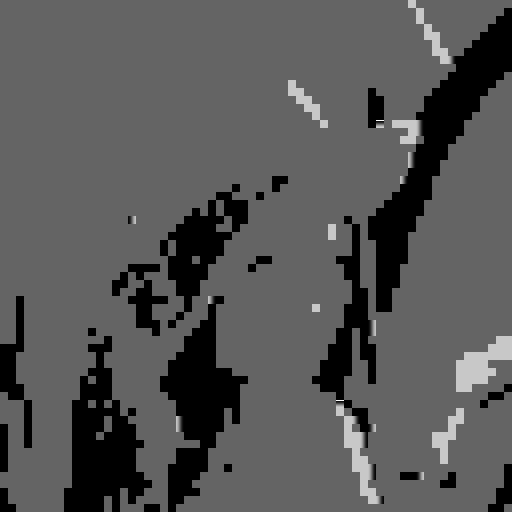

In [16]:
import numpy as np
from scipy.fft import dct, idct
from PIL import Image

# Define quantization matrix
quantization_matrix = np.array(
    [[16, 11, 10, 16, 24, 40, 51, 61],
     [12, 12, 14, 19, 26, 58, 60, 55],
     [14, 13, 16, 24, 40, 57, 69, 56],
     [14, 17, 22, 29, 51, 87, 80, 62],
     [18, 22, 37, 56, 68, 109, 103, 77],
     [24, 35, 55, 64, 81, 104, 113, 92],
     [49, 64, 78, 87, 103, 121, 120, 101],
     [72, 92, 95, 98, 112, 100, 103, 99]])

def jpeg_compress(image, quality):
    # Convert image to grayscale
    gray_image = image.convert('L')

    # Split into blocks
    blocks = block_split(gray_image)

    # Process each block
    compressed_data = []
    for block in blocks:
        # Apply DCT to each block
        dct_block = dct_2d(block.astype(np.float32))

        # Quantization
        quantized_block = np.round(dct_block / (quantization_matrix * quality))

        # Store quantized coefficients
        compressed_data.append(quantized_block)

    # Return compressed data
    return compressed_data

def jpeg_decompress(compressed_data, width, height, quality):
    # Initialize empty image
    image = Image.new('L', (width, height))

    # Inverse DCT and merge blocks
    block_idx = 0
    for y in range(0, height, 8):
        for x in range(0, width, 8):
            # Retrieve quantized block
            quantized_block = compressed_data[block_idx]

            # Inverse quantization
            dct_block = quantized_block * (quantization_matrix * quality)

            # Inverse DCT
            idct_block = idct_2d(dct_block)

            # Place block in the image
            block = Image.fromarray(idct_block.astype(np.uint8))
            image.paste(block, (x, y))

            # Increment block index
            block_idx += 1

    # Return the decompressed image
    return image

# Utility function to split the image into 8x8 blocks
def block_split(image):
    width, height = image.size
    blocks = []
    for y in range(0, height, 8):
        for x in range(0, width, 8):
            block = np.array(image.crop((x, y, x + 8, y + 8)))
            blocks.append(block)
    return blocks

# Utility function for 2D DCT
def dct_2d(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

# Utility function for 2D inverse DCT
def idct_2d(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

# Example usage
input_image = Image.open('kP0u2.png')

# Compress the image
compressed_data = jpeg_compress(input_image, quality=70)

# Decompress the image
decompressed_image = jpeg_decompress(compressed_data, width=input_image.width, height=input_image.height, quality=50)

# Save the decompressed image
decompressed_image.save('output.jpg')

decompressed_image.show()
